## 01. LightGBM 개념 정리

LightGBM은 Microsoft에서 공개한 Gradient Boosting 계열 라이브러리임.  
feature 값을 구간으로 나누는 histogram 방식을 사용해 빠르게 학습하는 것이 큰 특징임.

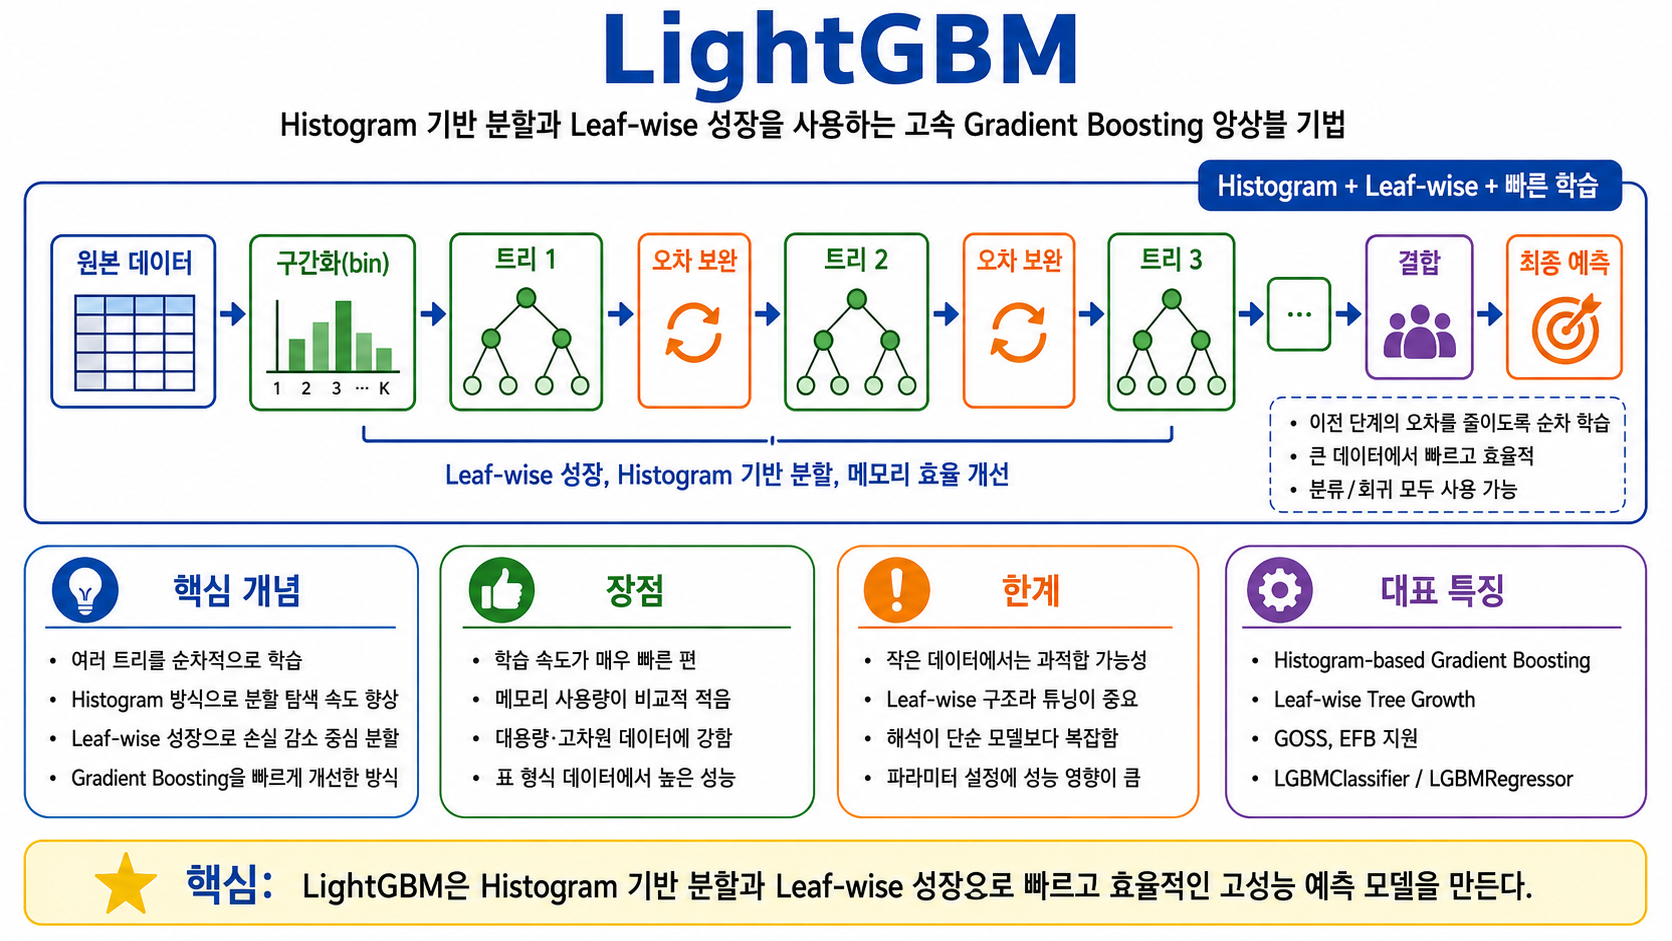

### 01-01. 배우는 이유

- LightGBM은 정형 데이터에서 빠른 학습과 좋은 성능으로 자주 사용되는 Boosting 라이브러리임.
- XGBoost와 함께 실무에서 많이 비교되는 대표 모델임.
- 데이터가 크거나 feature가 많을 때 Boosting을 효율적으로 쓰는 방법을 이해할 수 있음.

### 01-02. 어디서 사용하는가?

- 대용량 표 데이터의 분류/회귀 문제에서 사용함.
- 고객 행동 예측, 추천 후보 점수화, 위험 예측, 수요 예측 같은 실무 정형 데이터 문제에 자주 쓰임.
- 빠른 실험이 필요하거나 많은 하이퍼파라미터 후보를 비교해야 할 때 유용함.

### 01-03. 핵심 특징

- feature 값을 histogram 구간으로 묶어 계산량을 줄임.
- 큰 데이터셋, 많은 feature, 범주형 feature가 있는 문제에서 자주 사용됨.
- 기존 Gradient Boosting보다 빠르게 학습하면서 좋은 성능을 내는 경우가 많음.
- `LGBMClassifier`, `LGBMRegressor`를 사용하려면 LightGBM 라이브러리가 설치되어 있어야 함.

### 01-04. 이번 노트북에서 확인할 개선점

- Adult Income 분류 데이터에서 기존 모델과 `test_accuracy`를 비교함.
- California Housing 회귀 데이터에서 기존 모델과 `R2`, `RMSE`를 비교함.
- LightGBM이 항상 최고라는 뜻은 아니지만, 같은 조건에서 빠르고 강한 후보 모델이 될 수 있음을 확인함.


In [1]:
%pip install lightgbm

  Using cached lightgbm-4.6.0-py3-none-win_amd64.whl.metadata (17 kB)
Using cached lightgbm-4.6.0-py3-none-win_amd64.whl (1.5 MB)
Note: you may need to restart the kernel to use updated packages.


## 02. 실습 환경 준비

LightGBM이 설치되어 있다는 전제로 필요한 라이브러리를 바로 import함.  
비교 실험에서는 기존 모델과 LightGBM을 같은 데이터 분할, 같은 평가 지표로 비교함.


In [1]:
# 파일 경로 처리와 표 형태 결과 확인에 사용할 라이브러리
from pathlib import Path
import numpy as np
import pandas as pd

# train_test_split: 학습 데이터와 평가 데이터를 분리
from sklearn.model_selection import train_test_split

# 회귀 평가 지표
# r2_score: 회귀 모델의 설명력 확인
# root_mean_squared_error: 회귀 예측 오차를 원래 target 단위로 확인
from sklearn.metrics import r2_score, root_mean_squared_error

# LightGBM과 비교할 기존 모델
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    RandomForestRegressor,
    GradientBoostingRegressor,
)

# LGBMClassifier: LightGBM 분류 모델
# LGBMRegressor: LightGBM 회귀 모델
# LightGBM 라이브러리를 직접 import해 이후 예제에서 바로 사용함.
from lightgbm import LGBMClassifier, LGBMRegressor

## 03. Adult Income 분류 모델 비교

Adult Income 데이터는 나이, 직업, 교육 수준, 근무 시간 등을 이용해 소득이 `>50K`인지 예측하는 이진분류 데이터임.  
이번 셀에서는 기존 모델과 LightGBM을 같은 학습/평가 데이터에서 비교함.

비교 기준은 `test_accuracy`임.  
학습 점수와 평가 점수를 함께 봐야 과대적합 여부도 판단할 수 있음.


In [2]:
# Adult Income CSV는 헤더가 없는 파일이므로 컬럼명을 직접 지정함.
adult_columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num',
    'marital_status', 'occupation', 'relationship', 'race', 'sex',
    'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income'
]

# 노트북 실행 위치가 달라져도 CSV를 찾을 수 있도록 후보 경로를 차례대로 확인함.
adult_path = Path('data/adult_income.csv')

adult_df = pd.read_csv(adult_path, names=adult_columns, header=None)

# 문자열 값 앞뒤 공백을 제거함.
# Adult Income 원본에는 ' State-gov'처럼 앞에 공백이 붙은 값이 있음.
for col in adult_df.columns:
    if pd.api.types.is_string_dtype(adult_df[col]) or pd.api.types.is_object_dtype(adult_df[col]):
        adult_df[col] = adult_df[col].astype(str).str.strip()

# income은 맞혀야 할 target임. '>50K'이면 1, 아니면 0으로 변환함.
adult_X_raw = adult_df.drop(columns='income').replace('?', pd.NA)
adult_y = adult_df['income'].eq('>50K').astype(int)

adult_X = pd.get_dummies(adult_X_raw, dummy_na=True)

adult_X_train, adult_X_test, adult_y_train, adult_y_test = train_test_split(
    adult_X,
    adult_y,
    test_size=0.25,
    random_state=42,
    stratify=adult_y,
)

display(adult_df.head())
print(adult_df.shape)
print(adult_y.value_counts(normalize=True))

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


(32561, 15)
income
0    0.75919
1    0.24081
Name: proportion, dtype: float64


In [4]:
classification_models = {
    'decision_tree': DecisionTreeClassifier(
        max_depth=8,
        random_state=42,
    ),
    'random_forest' : RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        random_state=42,
        n_jobs=1,
    ),
    'gradient_boosting': GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.08,
        random_state=42,
    ),
    'lightgbm':LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31, # 하나의 트리가 가질 수 있는 리프노드의 수
        random_state=42,
        n_jobs=1
    )
}


classification_results = []

for name, model in classification_models.items():
    model.fit(adult_X_train, adult_y_train)

    classification_results.append({
        'model': name,
        'train_accuracy': model.score(adult_X_train, adult_y_train),
        'test_accuracy': model.score(adult_X_test, adult_y_test),
    })

classification_result_df = pd.DataFrame(classification_results).sort_values('test_accuracy', ascending=False)
display(classification_result_df)

best_existing_accuracy = classification_result_df.query("model != 'lightgbm'")['test_accuracy'].max()

lightgbm_accuracy = classification_result_df.loc[
    classification_result_df['model'] == 'lightgbm',
    'test_accuracy'
].iloc[0]

print(f'기존 모델 최고 test_accuracy: {best_existing_accuracy:.4f}')
print(f'LightGBM test_accuracy: {lightgbm_accuracy:.4f}')
print(f'차이: {lightgbm_accuracy - best_existing_accuracy:.4f}')

[LightGBM] [Info] Number of positive: 5881, number of negative: 18539
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004104 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 759
[LightGBM] [Info] Number of data points in the train set: 24420, number of used features: 92
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.240827 -> initscore=-1.148150
[LightGBM] [Info] Start training from score -1.148150


,model,train_accuracy,test_accuracy
3,lightgbm,0.898485,0.874831
2,gradient_boosting,0.871581,0.869426
0,decision_tree,0.861835,0.859108
1,random_forest,0.855242,0.851861


기존 모델 최고 test_accuracy: 0.8694
LightGBM test_accuracy: 0.8748
차이: 0.0054


## 04. California Housing 회귀 모델 비교

California Housing 데이터는 지역별 소득, 방 개수, 위치 정보 등을 이용해 주택 가격을 예측하는 회귀 데이터임.  
이번 셀에서는 기존 회귀 앙상블 모델과 LightGBM 회귀 모델을 비교함.

비교 기준은 `R2`와 `RMSE`임.

- `R2`: 1에 가까울수록 target 변동을 더 잘 설명함.
- `RMSE`: 예측 오차의 평균적인 크기이며 낮을수록 좋음.


In [6]:
housing_path = Path('data/california_housing.csv')

# MedHouseVal은 예측해야 할 집값 target임.
housing_df = pd.read_csv(housing_path)
housing_X = housing_df.drop(columns='MedHouseVal')
housing_y = housing_df['MedHouseVal']

housing_X_train, housing_X_test, housing_y_train, housing_y_test = train_test_split(
    housing_X,
    housing_y,
    test_size=0.25,
    random_state=42,
)


display(housing_df.head())
print(housing_X.shape, housing_y.shape)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


(20640, 8) (20640,)


In [7]:
regression_models = {
    'gradient_boosting': GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.08,
        random_state=42
    ),
    'random_forest': RandomForestRegressor(
        n_estimators=200,
        max_depth=14,
        random_state=42,
        n_jobs=1
    ),
    'lightgbm': LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        random_state=42,
        n_jobs=1,
        verbose=-1
    ),
}

regression_results = []

for name, model in regression_models.items():
    model.fit(housing_X_train, housing_y_train)
    housing_y_pred = model.predict(housing_X_test)

    regression_results.append({
        'model': name,
        'test_R2': r2_score(housing_y_test, housing_y_pred),
        'test_RMSE': root_mean_squared_error(housing_y_test, housing_y_pred),
    })

regression_result_df = pd.DataFrame(regression_results).sort_values('test_RMSE')
display(regression_result_df)

best_existing_rmse = regression_result_df.query("model != 'lightgbm'")['test_RMSE'].min()
lightgbm_rmse = regression_result_df.loc[
    regression_result_df['model'] == 'lightgbm',
    'test_RMSE'
].iloc[0]

print(f'기존 모델 최저 test_RMSE: {best_existing_rmse:.4f}')
print(f'LightGBM test_RMSE: {lightgbm_rmse:.4f}')
print(f'RMSE 감소량: {best_existing_rmse - lightgbm_rmse:.4f}')

,model,test_R2,test_RMSE
2,lightgbm,0.845351,0.452366
1,random_forest,0.803836,0.509478
0,gradient_boosting,0.797901,0.517127


기존 모델 최저 test_RMSE: 0.5095
LightGBM test_RMSE: 0.4524
RMSE 감소량: 0.0571


## 05. LightGBM 정리

- LightGBM은 Histogram 기반 Gradient Boosting 라이브러리임.
- 큰 데이터셋에서 빠른 학습을 목표로 함.
- 기존 모델과 비교할 때는 같은 데이터 분할과 같은 평가 지표를 사용해야 함.
- 이번 예제에서는 분류 `test_accuracy`, 회귀 `RMSE` 기준으로 LightGBM의 개선 가능성을 확인함.
- 항상 LightGBM이 최고라는 뜻은 아니며, 데이터 특성과 하이퍼파라미터에 따라 결과가 달라질 수 있음.
